Definitions and imports

In [1]:
import math
import matplotlib.pyplot as plt
import random

In [2]:
class Crop:
    def __init__(self, n_i, x_i, a_i, desc):
        self.n_i = n_i # productivity / kg per km2 per year
        self.x_i = x_i # selling price / USD per kg
        self.a_i = a_i # area allocated / km2
        self.desc = desc # for description purposes only

class Development:
    """ Class for potential developments on the given plot of land """
    def __init__(self, desc, crops=[], p=0.0, k=0.0, q=0.0, x_v=0.0, E_O=0.0, E_U=0.0, x_OE=0.0, x_IE=0.0, x_LV=815_448, x_m=0.0, x_s=0.0, x_w=0.0, n_w=0, x_d=667000.0, S_i=21, S_f=0.0, M_NYS=2344.0, M_IE=0.000294, a_d=0.0, M_d=52061, M_O=0.0, M_C=0.0, B_f=0.0, B_n=0.0, B_i=3099, color="#000000"):
        self.desc = desc # description of chosen development

        # agriculture
        self.crops = crops # list of potentially viable crops to grow (list of class Crop)

        # tourism
        self.p = p # stable maximum number of tourists after many years
        self.k = k # constant to fit logistic regression curve for number of tourists
        self.q = q # constant of rate of growth of number of tourists
        self.x_v = x_v # average expenditure per tourist / USD

        # energy
        self.E_O = E_O # total energy produced per year / kWh
        self.E_U = E_U # total energy used per year / kWh
        self.x_OE = x_OE # market selling rate of energy / USD per kWh
        self.x_IE = x_IE # market selling rate of energy / USD per kWh

        # economic
        self.x_LV = x_LV # annual avg land value of urban developed land in NYS / USD
        self.x_m = x_m # cost to operate and maintain entire system annually / USD
        self.x_s = x_s # one time setup cost / USD
        self.x_w = x_w # average wage per worker per year / USD
        self.n_w = n_w # number of workers
        self.x_d = x_d # deforestation cost / USD per km2

        # social
        self.S_i = S_i # initial social index score
        self.S_f = S_f # final social index score

        # carbon emissions
        self.M_NYS = M_NYS # emissions of NYS per unit area / MtCO2e per km2
        self.M_IE = M_IE # emissions from imported energy / MtCO2e per kWh
        self.a_d = a_d # area to be deforested for construction / km2
        self.M_d = M_d # emissions form deforestation / MtCO2e per km2
        self.M_O = M_O # annual emisssion from operations / MtCO2e per year
        self.M_C = M_C # one time emissions from construction / MtCO2e

        # biodiversity
        self.B_f = B_f # final number of species
        self.B_n = B_n # final number of invasive species
        self.B_i = B_i # initial number of species

        # WEIGHTAGES
        self.economic_weight = 0.6
        self.social_weight = 0.2
        self.environmental_weight = 0.1 # per factor (i.e. 0.1 x 2 = 0.2)

        self.color = color
        self.wk = 6

    """ FUNCTION """
    def S_q(self, x, k):
        return math.tanh(x/(self.wk*k))

    """ ECONOMIC """
    def P_A(self, t):
        overall_P_A = 0
        for i in self.crops:
            overall_P_A += (i.n_i)*(i.x_i)*(i.a_i)*t
        return overall_P_A

    def n_v(self, t):
        return self.p/(1+math.e**(-(self.k+self.q*t)))
    def P_T(self, t):
        overall_P_T = 0
        for i in range(1, t+1):
            overall_P_T += self.n_v(i)*self.x_v
        return overall_P_T

    def P_OE(self, t):
        return max(0, self.E_O-self.E_U)*self.x_OE*t

    def P(self, t):
        return self.P_A(t) + self.P_T(t) + self.P_OE(t)

    def C(self, t):
        C_IE = max(0,self.E_U-self.E_O)*self.x_IE
        operation_maintenance_costs = self.x_m
        deforestation_cost = self.a_d * self.x_d
        setup_cost = self.x_s
        return (C_IE+operation_maintenance_costs)*t + setup_cost + deforestation_cost

    def V(self, t):
        return self.x_LV*t

    """ SOCIAL """
    def delta_S(self):
        return self.S_f - self.S_i

    """ ENVIRONMENTAL """
    def M_S(self, t):
        return self.M_NYS*t
    
    def M_L(self, t):
        energy_emissions = (self.E_U-self.E_O)*self.M_IE  
        deforestation_emissions = self.a_d*self.M_d
        return ((energy_emissions+self.M_O)*t + deforestation_emissions + self.M_C)/3

    def LANDI(self, t):
        economic_score = self.S_q((self.P(t)-self.C(t)),self.V(t))
        social_score = self.delta_S()/(50-self.S_i)
        environmental_carbon_score = self.S_q(self.M_S(t) - self.M_L(t),self.M_S(t))
        environmental_biodiversity_score = (self.B_f - 5*self.B_n) / self.B_i
        return self.economic_weight*economic_score + self.social_weight*social_score + self.environmental_weight*environmental_carbon_score + self.environmental_weight*environmental_biodiversity_score

Land use efficiency (Task 2)

In [3]:
# Task 2: Definitions of options and time domain

options = [
    Development("No development", S_f=21, a_d=0, B_f=3099, B_n=0, color="#565ed6"),
    Development("Crop farm", crops=[Crop(2500000, 1.28, 0.5, "Peppers"), Crop(1882140, 1.63, 0.4, "Brussel Sprouts"), Crop(3000000, 1.73, 0.7, "Cauliflower")], p=0, E_U=39_400, E_O=0, x_m=4_777_608, x_s=333_480, S_f=28, a_d=1.14, M_O=346, M_C=55.97, B_f=2098, B_n=37, color="#87ae73"),
    Development("Solar array", p=0, k=0, q=0, E_U=0, E_O=914_000_000, x_OE=0.047, x_m=14_224_000, x_s=695500000, n_w=0, S_f=22, a_d=2.04, M_O=0, M_C=537432, B_f=3005, B_n=0, color="#fcba03"),
    Development("Agritourist centre", crops=[Crop(2500000, 1.28, 0.24, "Peppers"), Crop(1120372, 1.38, 0.24, "Strawberries"), Crop(3000000, 0.60, 0.24, "Lettuce"), Crop(1500000, 0.43, 0.24, "Carrot")], p=147_520, k=-6, q=1.766, x_v=601, E_U = 19_086_000, S_f=36, a_d=1.576, M_O=53_674, M_C=339_797, B_f=548, B_n=49, x_s=271_692_000, x_m=56_171_000, color="#eb3d34"),
]

# for time
lower_limit = 1
upper_limit = 25

plt.rcParams.update({'font.size': 13, 'font.family': "Times New Roman"})

<Figure size 640x480 with 0 Axes>

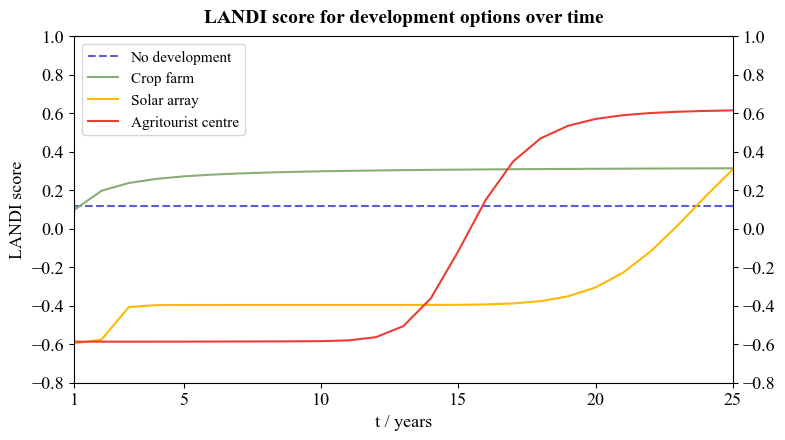

In [4]:
# Task 2: Plot of LANDI v time

%matplotlib inline
plt.clf()
fig, ax = plt.subplots()
x_val = []
y_val = []
for dev in options:
    x_val.append([i for i in range(lower_limit, upper_limit+1)])
    y_val.append([dev.LANDI(i) for i in range(lower_limit, upper_limit+1)])
    ax.plot(x_val[-1], y_val[-1], label=dev.desc, linestyle="--" if dev.desc=="No development" else "-", color=dev.color)

ax.set_xlabel("t / years")
ax.set_ylabel("LANDI score")
ax.set_title("LANDI score for development options over time", pad=10, fontsize=14, fontweight="bold")
ax.set_xlim(lower_limit, upper_limit)
ax.set_ylim(-0.8, 1)
ax.legend(fontsize=11)
ax.yaxis.set_ticks_position('both')
ax.tick_params(labelright=True)


x_ticks = [1] + [i for i in range(5, upper_limit+1, 5)]
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_ticks)
fig.set_figwidth(8.5)
fig.set_figheight(4.5)

plt.show()
fig.savefig("figures/graph-LANDI-score.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

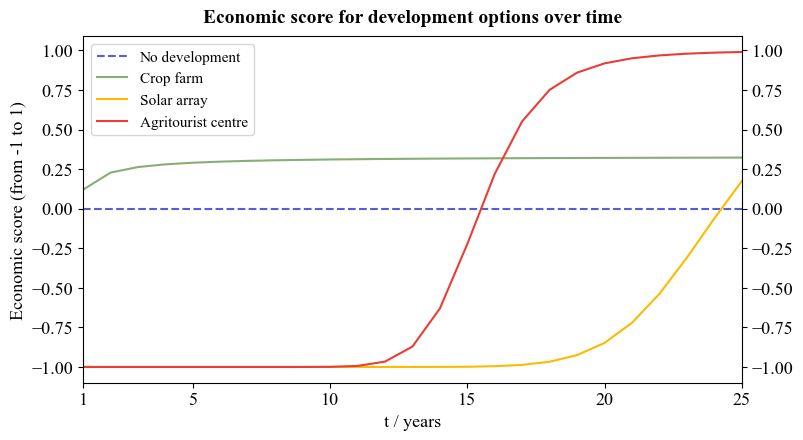

In [5]:
# Task 2: Plot of Economic Score v time

%matplotlib inline
plt.clf()
fig, ax = plt.subplots()

for dev in options:
    ax.plot([i for i in range(lower_limit, upper_limit+1)], 
            [dev.S_q(dev.P(i)-dev.C(i),dev.V(i)) for i in range(lower_limit, upper_limit+1)], 
            label=dev.desc, 
            linestyle="--" if dev.desc=="No development" else "-", 
            color=dev.color
    )

ax.set_xlabel("t / years")
ax.set_ylabel("Economic score (from -1 to 1)")
ax.set_title("Economic score for development options over time", pad=10, fontsize=14, fontweight="bold")
ax.set_xlim(lower_limit, upper_limit)
# ax.set_ylim(-1, 1)
ax.legend(fontsize=11)
ax.yaxis.set_ticks_position('both')
ax.tick_params(labelright=True)


x_ticks = [1] + [i for i in range(5, upper_limit+1, 5)]
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_ticks)

fig.set_figwidth(8.5)
fig.set_figheight(4.5)

plt.show()
fig.savefig("figures/graph-EC-score.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

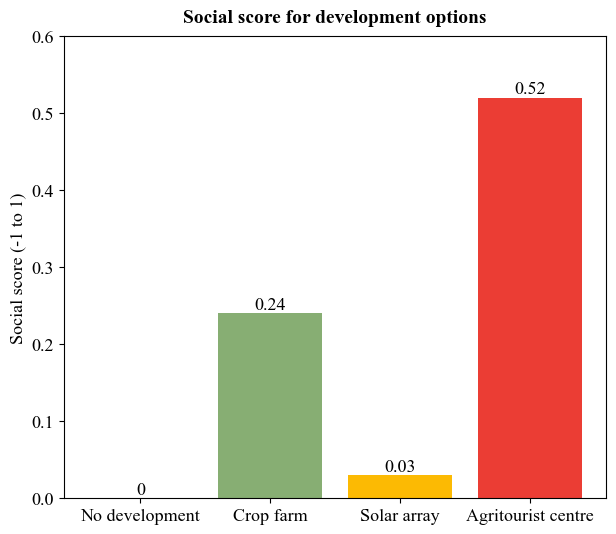

In [6]:
# Task 2: Plot of Social Score

%matplotlib inline
plt.clf()
fig, ax = plt.subplots()

bars = ax.bar([dev.desc for dev in options], 
       [round((dev.S_f-dev.S_i)/(50-dev.S_i),2) for dev in options], 
       color=[dev.color for dev in options], 
       hatch=[("//" if dev.desc=="No development" else "") for dev in options]
)
ax.bar_label(bars)

ax.set_ylabel("Social score (-1 to 1)")
ax.set_title("Social score for development options", pad=10, fontsize=14, fontweight="bold")
ax.set_ylim(0.0, 0.6)

fig.set_figwidth(7)
fig.set_figheight(6)

plt.show()
fig.savefig("figures/graph-SO-score.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

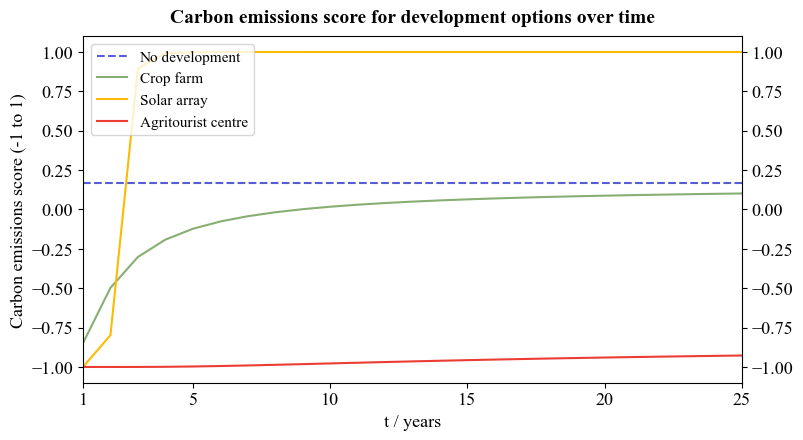

In [7]:
# Task 2: Plot of Carbon Emissions Score v Time

%matplotlib inline
plt.clf()
fig, ax = plt.subplots()

for dev in options:
    ax.plot([i for i in range(lower_limit, upper_limit+1)], 
            [dev.S_q(dev.M_S(i) - dev.M_L(i),dev.M_S(i)) for i in range(lower_limit, upper_limit+1)], 
            label=dev.desc, 
            linestyle="--" if dev.desc=="No development" else "-", 
            color=dev.color
    )

ax.set_xlabel("t / years")
ax.set_ylabel("Carbon emissions score (-1 to 1)")
ax.set_title("Carbon emissions score for development options over time", pad=10, fontsize=14, fontweight="bold")
ax.set_xlim(lower_limit, upper_limit)
ax.legend(fontsize=11)
ax.yaxis.set_ticks_position('both')
ax.tick_params(labelright=True)

x_ticks = [1] + [i for i in range(5, upper_limit+1, 5)]
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_ticks)

fig.set_figwidth(8.5)
fig.set_figheight(4.5)

plt.show()
fig.savefig("figures/graph-CE-score.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

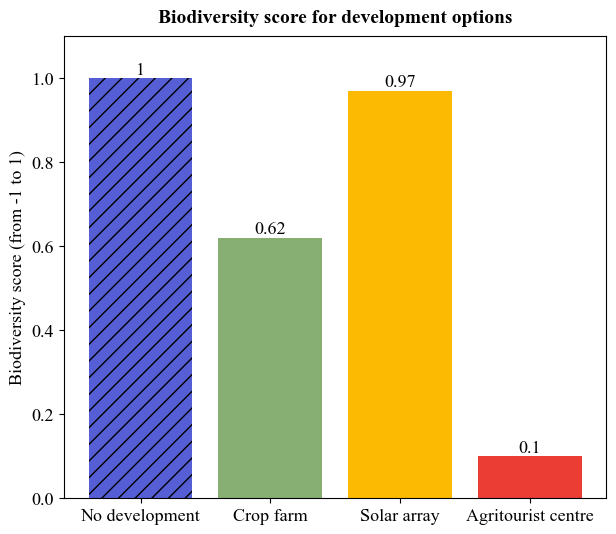

In [8]:
# Task 2: Plot of Biodiversity Score

%matplotlib inline
plt.clf()
fig, ax = plt.subplots()

bars = ax.bar([dev.desc for dev in options], 
       [round((dev.B_f-5*dev.B_n)/dev.B_i,2) for dev in options], 
       color=[dev.color for dev in options], 
       hatch=[("//" if dev.desc=="No development" else "") for dev in options]
)
ax.bar_label(bars)

ax.set_ylabel("Biodiversity score (from -1 to 1)")
ax.set_title("Biodiversity score for development options", pad=10, fontsize=14, fontweight="bold")
ax.set_ylim(0.0, 1.1)
ax.set_yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])

fig.set_figwidth(7)
fig.set_figheight(6)

plt.show()
fig.savefig("figures/graph-BD-score.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

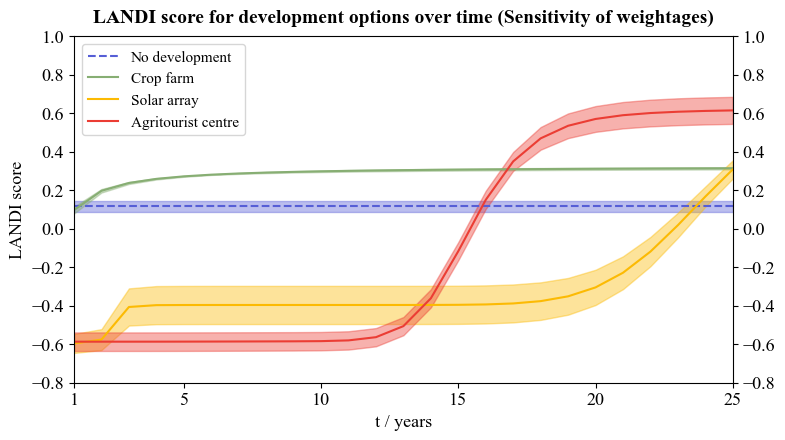

Economic 0.55 - 0.65
Social 0.15 - 0.25
Environmental (combined) 0.15 - 0.25


In [9]:
# Task 2: Sensitivity Analysis (Weightages)

min_score = [[1 for _ in range(lower_limit, upper_limit+1)] for _ in range(len(options))]
max_score = [[-1 for _ in range(lower_limit, upper_limit+1)] for _ in range(len(options))]

# store to check for randomness
economic_weights = []
social_weights = []
environmental_weights = []

# options, x_val, y_val, upper_limit, lower_limit already defined
num_runs = 10000

# define inaccuracy
inaccuracy_threshold = 0.05

for _ in range(num_runs):
    economic_weight = random.uniform(0.6-inaccuracy_threshold, 0.6+inaccuracy_threshold) # random value from 0.6 +- 0.05
    diff = inaccuracy_threshold-abs(0.6-economic_weight)
    social_weight = random.uniform(0.2-diff, 0.2+diff) # random value from 0.2 +- 0.05, BUT ensuring that envt weight will only be +- 0.05
    environmental_weight = (1-economic_weight-social_weight)/2 
    economic_weights.append(economic_weight)
    social_weights.append(social_weight)
    environmental_weights.append(environmental_weight*2)

    for count, i in enumerate(options):
        i.economic_weight =  economic_weight
        i.social_weight = social_weight
        i.environmental_weight = environmental_weight
        calculated_score = [i.LANDI(t) for t in range(lower_limit, upper_limit+1)]
        min_score[count]=[min(min_score[count][j], calculated_score[j]) for j in range(len(calculated_score))]
        max_score[count]=[max(max_score[count][j], calculated_score[j]) for j in range(len(calculated_score))]

plt.clf()
fig, ax = plt.subplots()
for count, option in enumerate(options):
    ax.fill_between(x_val[count], min_score[count], max_score[count], color=option.color, alpha=.4)
    ax.plot(x_val[count], y_val[count], label=option.desc, linestyle="--" if option.desc=="No development" else "-", color=option.color)

ax.set_xlabel("t / years")
ax.set_ylabel("LANDI score")
ax.set_title("LANDI score for development options over time (Sensitivity of weightages)", pad=10, fontsize=14, fontweight="bold")
ax.set_xlim(lower_limit, upper_limit)
ax.set_ylim(-0.8, 1)
ax.legend(fontsize=11)
ax.yaxis.set_ticks_position('both')
ax.tick_params(labelright=True)

x_ticks = [1] + [i for i in range(5, upper_limit+1, 5)]
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_ticks)

fig.set_figwidth(8.5)
fig.set_figheight(4.5)

plt.show()
fig.savefig("figures/graph-sensitivity-analysis-weightages.png", dpi=300, bbox_inches="tight")

print("Economic", round(min(economic_weights),3), "-", round(max(economic_weights),3))
print("Social", round(min(social_weights),3), "-", round(max(social_weights),3))
print("Environmental (combined)", round(min(environmental_weights),3), "-", round(max(environmental_weights),3))


<Figure size 640x480 with 0 Axes>

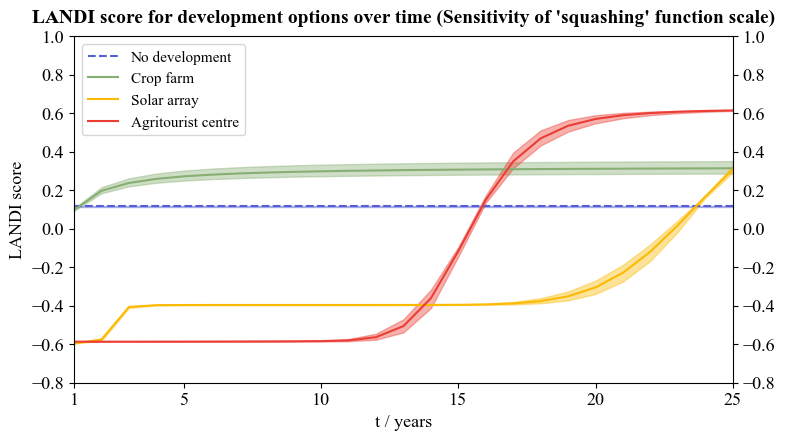

Scaling factor 5.0 - 7.0


In [10]:
# Task 2: Sensitivity Analysis (Scaling constant)

min_score = [[1 for _ in range(lower_limit, upper_limit+1)] for _ in range(len(options))]
max_score = [[-1 for _ in range(lower_limit, upper_limit+1)] for _ in range(len(options))]

# store to check for randomness
scaling_factors = []

# options, x_val, y_val, upper_limit, lower_limit already defined
num_runs = 10000

# define inaccuracy
inaccuracy_threshold = 1

for count, i in enumerate(options):
    i.economic_weight =  0.6
    i.social_weight = 0.2
    i.environmental_weight = 0.1

for _ in range(num_runs):
    wk = random.uniform(6-inaccuracy_threshold, 6+inaccuracy_threshold)
    scaling_factors.append(wk)
    for count, i in enumerate(options):
        i.wk = wk
        calculated_score = [i.LANDI(t) for t in range(lower_limit, upper_limit+1)]
        min_score[count]=[min(min_score[count][j], calculated_score[j]) for j in range(len(calculated_score))]
        max_score[count]=[max(max_score[count][j], calculated_score[j]) for j in range(len(calculated_score))]

plt.clf()
fig, ax = plt.subplots()
for count, option in enumerate(options):
    ax.fill_between(x_val[count], min_score[count], max_score[count], color=option.color, alpha=.4)
    ax.plot(x_val[count], y_val[count], label=option.desc, linestyle="--" if option.desc=="No development" else "-", color=option.color)

ax.set_xlabel("t / years")
ax.set_ylabel("LANDI score")
ax.set_title("LANDI score for development options over time (Sensitivity of 'squashing' function scale)", pad=10, fontsize=14, fontweight="bold")
ax.set_xlim(lower_limit, upper_limit)
ax.set_ylim(-0.8, 1)
ax.legend(fontsize=11)
ax.yaxis.set_ticks_position('both')
ax.tick_params(labelright=True)

x_ticks = [1] + [i for i in range(5, upper_limit+1, 5)]
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_ticks)

fig.set_figwidth(8.5)
fig.set_figheight(4.5)

plt.show()
fig.savefig("figures/graph-sensitivity-analysis-scaling.png", dpi=300, bbox_inches="tight")

print("Scaling factor", round(min(scaling_factors),3), "-", round(max(scaling_factors),3))

Task 3

In [13]:
# Redefinition of options for task 3

options = [
    Development("No development", S_f=21, a_d=0, B_f=3099, B_n=0, color="#565ed6"),
    Development("Crop farm", crops=[Crop(2500000, 1.28, 0.5, "Peppers"), Crop(1882140, 1.63, 0.4, "Brussel Sprouts"), Crop(3000000, 1.73, 0.7, "Cauliflower")], p=0, E_U=39_400, E_O=0, x_m=4_885_000, x_s=314_000, S_f=28, a_d=1.14, M_O=346, M_C=55.97, B_f=2098, B_n=37, color="#87ae73", x_IE=0.1308),
    Development("Solar array", p=0, k=0, q=0, E_U=0, E_O=914_000_000, x_m=14_224_000, x_s=655_091_000, n_w=0, S_f=22, a_d=2.04, M_O=0, M_C=537432, B_f=3005, B_n=0, color="#fcba03", x_OE=0.0646),
    Development("Agritourist centre", crops=[Crop(2500000, 1.28, 0.24, "Peppers"), Crop(1120372, 1.38, 0.24, "Strawberries"), Crop(3000000, 0.60, 0.24, "Lettuce"), Crop(1500000, 0.43, 0.24, "Carrot")], p=192_253, k=-6, q=1.766, x_v=601, E_U = 19_086_000, S_f=36, a_d=1.576, M_O=53_674, M_C=339_797, B_f=548, B_n=49, x_s=255_906_000, x_m=60_253_000, color="#eb3d34", x_IE=0.1308)
]
for option in options:
    option.wk = 6
    option.economic_weight=0.6
    option.social_weight=0.2
    option.environmental_weight=0.1

54520471.40639973


<Figure size 640x480 with 0 Axes>

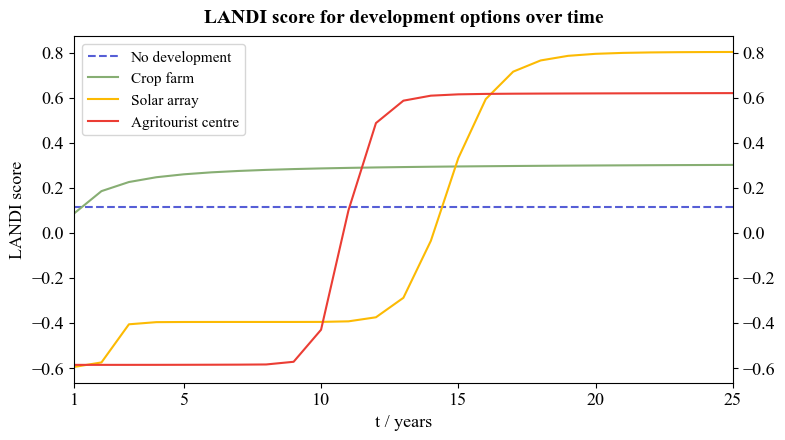

In [14]:
# Task 3: Plot of LANDI v time

%matplotlib inline
plt.clf()
fig, ax = plt.subplots()

x_val = []
y_val = []
for dev in options:
    x_val.append([i for i in range(lower_limit, upper_limit+1)])
    y_val.append([dev.LANDI(i) for i in range(lower_limit, upper_limit+1)])
    ax.plot(x_val[-1], y_val[-1], label=dev.desc, linestyle="--" if dev.desc=="No development" else "-", color=dev.color)

val=options[-1]
print(val.P(25)-val.C(25)-(val.P(24)-val.C(24)))

ax.set_xlabel("t / years")
ax.set_ylabel("LANDI score")
ax.set_title("LANDI score for development options over time", pad=10, fontsize=14, fontweight="bold")
ax.set_xlim(lower_limit, upper_limit)
# ax.set_ylim(-0.8, 1)
ax.legend(fontsize=11)
ax.yaxis.set_ticks_position('both')
ax.tick_params(labelright=True)


x_ticks = [1] + [i for i in range(5, upper_limit+1, 5)]
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_ticks)
fig.set_figwidth(8.5)
fig.set_figheight(4.5)

plt.show()
fig.savefig("figures/graph-LANDI-score-t3.png", dpi=300, bbox_inches="tight")